# Time Series Analysis: Similarity

In [2]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Similarity Measures

A lot of time series analysis algorithms depend on the similarity between two time series or subsequences. As time series can be understood as a vector with length $n$, this vector would point to a point in $n$-dimensional space. The similarity between two subsequences could then be understood as the straight-line distance between their respective points in space - the euclidian distance (ED).

However, this approach assumes that both time series are of the same length. Furthermore, a time series could have a high ED to a shifted version of itself, although they could be understood as very similar. 

To solve this, Dynamic Time Warping (DTW) introduces a more "elastic" similarity measure.

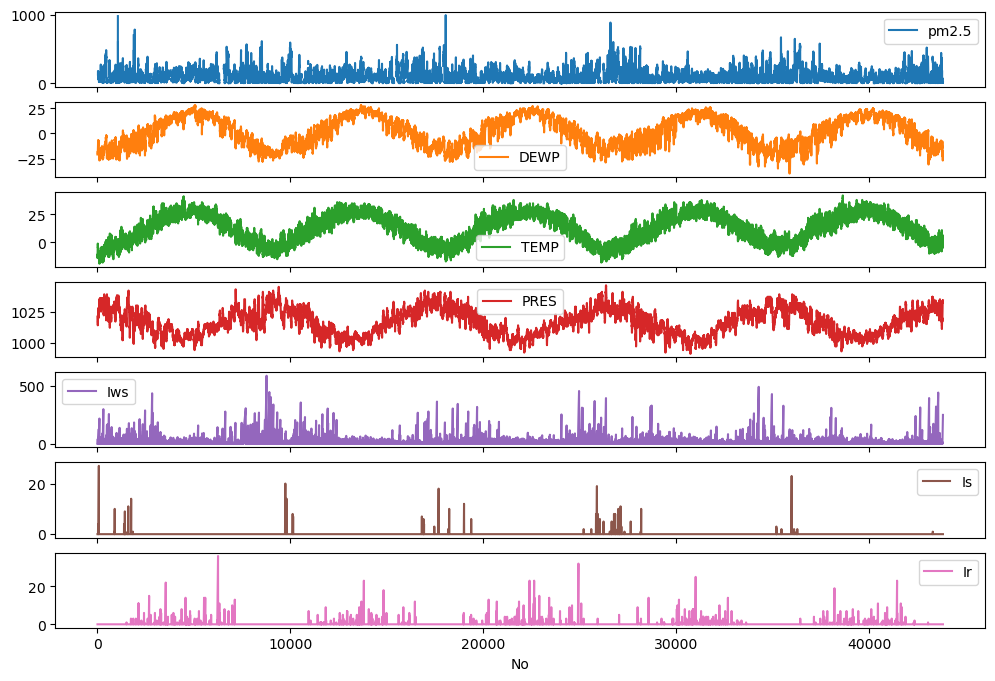

In [3]:
# example time series
# synthetic


# real world examples
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"
df_pollution = pd.read_csv(url, header=0, index_col=0)
df_pollution.drop(columns=['year', 'month', 'day', 'hour', 'cbwd'], inplace=True)

df_pollution.plot(
    subplots=True, # Plots each time series on a separate axis
    figsize=(12, 8))
plt.show()

### ED

$$ED(X, Y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

In [4]:
# or use numpy.linalg.norm(a-b)
def euclidian_distance(ts1, ts2):
    # note that "-" and "**" are piecewise operations in numpy
    return np.sqrt(np.sum((ts1 - ts2) ** 2))

## DTW

$$DTW(X,Y) = \min_{\pi \in \mathcal{A}(X, Y)} \left( \sqrt{\sum_{(i,j) \in \pi} (x_i - y_i)^2} \right)$$

In [5]:
from tslearn.metrics import dtw

def dtw_manual(ts1, ts2, constraint):
    # 1: Variables
    n = len(ts1)
    m = len(ts2)

    w = max(constraint, abs(n-m))
    
    # 2: Matrix Initialization
    C = np.full((n + 1, m + 1), np.inf)
    C[0, 0] = 0

    # 3: Main loop
    for i in range(1, n+1):
        for j in range(max(1, i-w), min(m+1, i+w+1)): # for j in range(1, m+1) without constraint
            dist = (ts1[i-1] - ts2[j-1]) ** 2   # squared ED between data points
            
            C[i, j] = dist + min(C[i-1, j],     # Insertion
                                 C[i, j-1],     # Deletion
                                 C[i-1, j-1]    # Match
                                 )

    return np.sqrt(C[n, m]) # final distance

In [24]:
%%time
dist1 = dtw_manual(df_pollution["TEMP"].iloc[:15000].values, df_pollution["PRES"].iloc[:15000].values, constraint=1)

CPU times: user 153 ms, sys: 995 ms, total: 1.15 s
Wall time: 1.13 s


In [25]:
%%time
dist2 = dtw(df_pollution["TEMP"].iloc[:15000].values, df_pollution["PRES"].iloc[:15000].values, global_constraint="sakoe_chiba")

CPU times: user 326 ms, sys: 450 ms, total: 776 ms
Wall time: 763 ms


In [21]:
np.isclose(dist1, dist2)

np.True_

In [28]:
df_pollution.shape

(43824, 7)

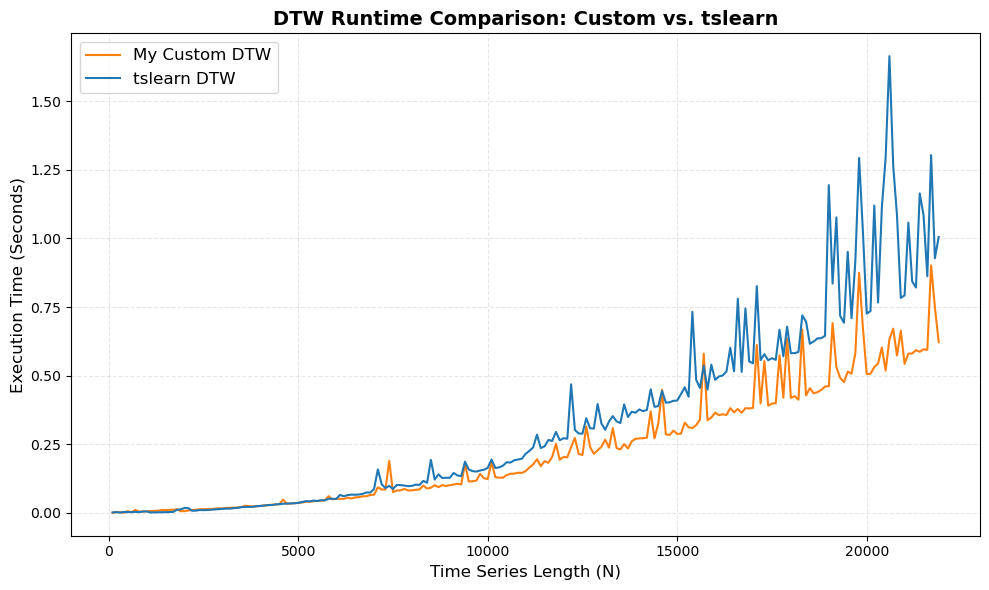

In [32]:
import time

# ==========================================
# 2. Benchmarking Parameters
# ==========================================
max_length, _ = df_pollution.shape
max_length //= 2
step_size = 100

# Arrays to store the results
lengths = list(range(100, max_length + 1, step_size))
times_custom = []
times_tslearn = []

# ==========================================
# 3. Execution Loop
# ==========================================
ts1 = df_pollution["TEMP"].values
ts2 = df_pollution["PRES"].values

for L in lengths:
    # --- Time Custom DTW ---
    start_time = time.perf_counter()
    dtw_manual(ts1[:L], ts2[:L], constraint=1)
    end_time = time.perf_counter()
    times_custom.append(end_time - start_time)
    
    # --- Time tslearn DTW ---
    start_time = time.perf_counter()
    dtw(ts1[:L], ts2[:L], global_constraint="sakoe_chiba")
    end_time = time.perf_counter()
    times_tslearn.append(end_time - start_time)
    
# ==========================================
# 4. Plotting the Results
# ==========================================
plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(lengths, times_custom, label='My Custom DTW', color='#ff7f0e')
plt.plot(lengths, times_tslearn, label='tslearn DTW', color='#1f77b4')

# Aesthetics
plt.title("DTW Runtime Comparison: Custom vs. tslearn", fontsize=14, fontweight='bold')
plt.xlabel("Time Series Length (N)", fontsize=12)
plt.ylabel("Execution Time (Seconds)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

## 2. Similarity Search

In [10]:
import heapq

def knn_search(query_ts, ts_set, k, distance_measure):
    heap = []
    max_dist = np.inf

    for i, ts in enumerate(ts_set):
        if distance_measure == "DTW":
            dist = dtw(query_ts, ts)
        else:
            dist = euclidian_distance(query_ts, ts)

        if len(heap) < k:
            heapq.heappush(heap, (-dist, i))

            if len(heap) == k:
                max_dist = - heap[0][0]

        elif dist < max_dist:
            heapq.heappushpop(heap, (-dist, i))
            max_dist = - heap[0][0]

    return heapq.nlargest(k, heap)

## 3. Lower Bounding

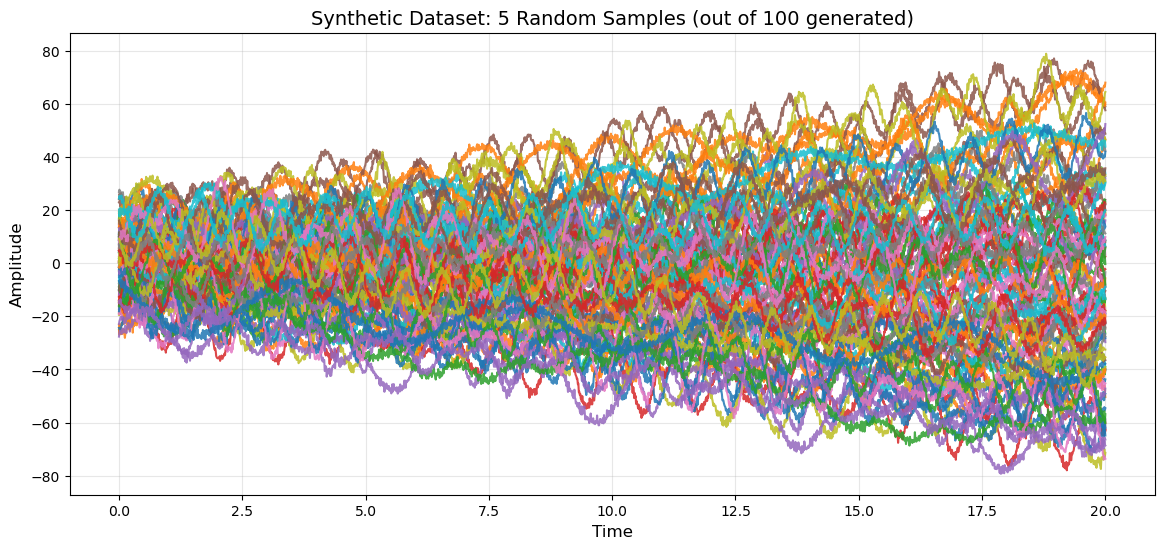

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global Control Parameters
# ==========================================
n_ts = 100           # Number of individual time series to generate
ts_length = 2000    # Number of data points per time series
noise_level = 1   # Standard deviation of the white noise

# Set seed for reproducibility (optional)
np.random.seed(42)

# ==========================================
# 2. Setup Dimensions for Broadcasting
# ==========================================
# Time vector reshaped to (ts_length, 1) to act as the vertical axis
t = np.linspace(0, 20, ts_length).reshape(-1, 1)

# ==========================================
# 3. Individual Random Characteristics
# ==========================================
# We generate arrays of shape (1, n_ts) so each series gets its own unique parameter

# Random frequencies for the sine and cosine waves (e.g., between 0.1 and 1.5 Hz)
freq_sin = np.random.uniform(0.1, 1.5, size=(1, n_ts))
freq_cos = np.random.uniform(0.1, 1.5, size=(1, n_ts))

# Random amplitudes (how tall the waves are)
amp_sin = np.random.uniform(2.0, 10.0, size=(1, n_ts))
amp_cos = np.random.uniform(2.0, 10.0, size=(1, n_ts))

# Random phase shifts (sliding the wave left or right)
phase_sin = np.random.uniform(0, 2 * np.pi, size=(1, n_ts))
phase_cos = np.random.uniform(0, 2 * np.pi, size=(1, n_ts))

# Random linear trends (drifting up or down over time)
trends = np.random.uniform(-3.0, 3.0, size=(1, n_ts))

# Random starting offsets (y-intercept)
intercepts = np.random.uniform(-20, 20, size=(1, n_ts))

# ==========================================
# 4. Construct the Time Series Set
# ==========================================
# Base Signals
wave_sin = amp_sin * np.sin(2 * np.pi * freq_sin * t + phase_sin)
wave_cos = amp_cos * np.cos(2 * np.pi * freq_cos * t + phase_cos)
linear_drift = (trends * t) + intercepts

# Noise Matrix of shape (ts_length, n_ts)
noise = np.random.normal(loc=0, scale=noise_level, size=(ts_length, n_ts))

# Combine all matrices! 
# ts_matrix is now a perfect (1000, 50) numpy array
ts_matrix = wave_sin + wave_cos + linear_drift + noise

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(14, 6))

# Plot a subset (first 5 series) so the chart isn't an unreadable mess
plt.plot(t, ts_matrix[:, :], alpha=0.85, linewidth=1.5)

plt.title(f"Synthetic Dataset: 5 Random Samples (out of {n_ts} generated)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import dtw, lb_keogh

def lower_bound_search(ts_query, ts_set, epsilon, use_lb=True):
    results = []
    znorm = TimeSeriesScalerMeanVariance()
    ts_query_normed = znorm.fit_transform(ts_query.reshape(1, -1)).flatten()

    for i, ts in enumerate(ts_set.T):
        ts_normed = znorm.fit_transform(ts.reshape(1, -1)).flatten()

        if use_lb:
            lb_dist = lb_keogh(ts_query_normed, ts_normed)

            if lb_dist > epsilon:
                continue

        exact_dist = dtw(ts_query_normed, ts_normed, global_constraint="sakoe_chiba")

        if exact_dist <= epsilon:
            results.append((exact_dist, i))
    
    return results

/home/moritz/miniconda3/envs/unibz-tsa-examples/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [13]:
%%time
results_lb_on = lower_bound_search(ts_matrix[:, 0], ts_matrix[:, 1:], 40, use_lb=True)

CPU times: user 1.36 s, sys: 22.5 ms, total: 1.38 s
Wall time: 1.38 s


In [14]:
%%time
results_lb_off = lower_bound_search(ts_matrix[:, 0], ts_matrix[:, 1:], 40, use_lb=False)

CPU times: user 740 ms, sys: 2.33 ms, total: 742 ms
Wall time: 740 ms


The LB result is equal: True


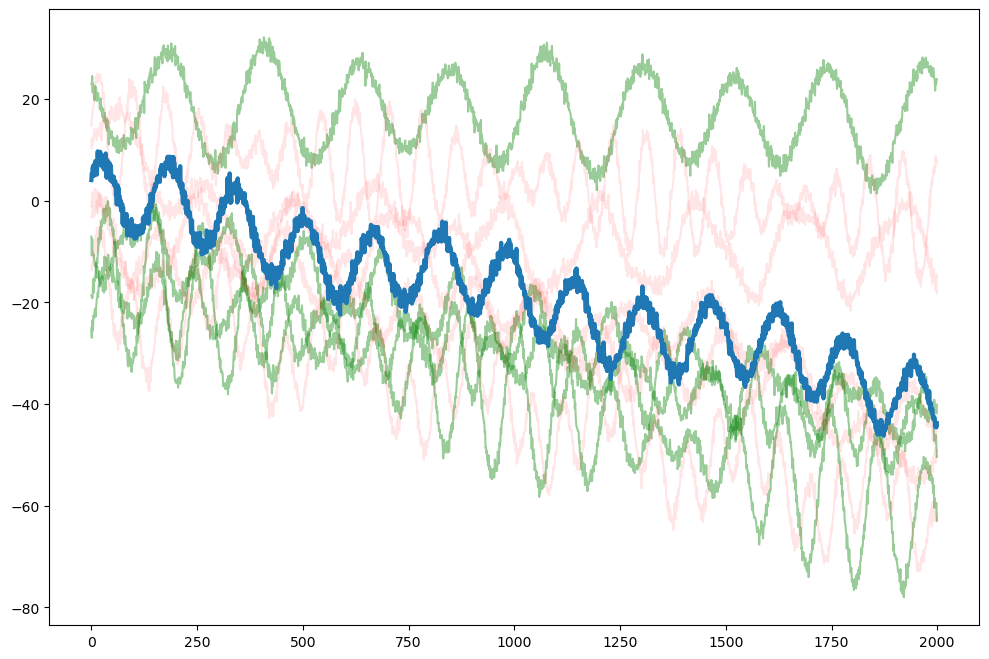

In [15]:
print(f"The LB result is equal: {results_lb_off == results_lb_on}")
eps_similar_ts = [idx for _, idx in results_lb_off]

plt.figure(figsize=(12,8))
plt.plot(
    ts_matrix[:, eps_similar_ts][:,:5],
    color="green",
    alpha=0.4
)

plt.plot(
    np.delete(ts_matrix, eps_similar_ts, axis=1)[:,:5],
    color="red",
    alpha=0.1
)
plt.plot(ts_matrix[:, 0], linewidth=3)

plt.show()